In [1]:
from typing import List, TypedDict
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_huggingface import HuggingFaceEndpoint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel
#

load_dotenv()

C:\Users\itssp\AppData\Local\Temp\ipykernel_9412\1224799246.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
D:\Downloads\CRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3263.68it/s]


In [15]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0,
)

In [3]:
docs = (
    PyPDFLoader("./Books/book1.pdf").load()
    #PyPDFLoader("./Books/book2.pdf").load(),
    #PyPDFLoader("./Books/book3.pdf").load()
)

In [4]:
len(docs)

758

In [5]:
import sys

print(sys.executable)

D:\Downloads\CRAG\.venv\Scripts\python.exe


In [6]:
import sys

print(sys.executable)

import langchain_community

print("SUCCESS")

D:\Downloads\CRAG\.venv\Scripts\python.exe
SUCCESS


In [7]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [8]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [9]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={'k': 4})

In [10]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [11]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [12]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system",
         "Answer only from the context. If not in context, say you don't know. Don't give the answers from the parametric knowledge"),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)


def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

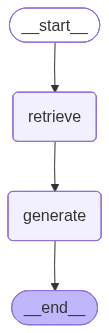

In [13]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [16]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])
print(res["docs"])

In the context of deep learning, a transformer is not explicitly mentioned in the provided text. However, the text does mention "convolutional neural network" which is a type of neural network architecture that is often used in conjunction with transformers in modern deep learning models.

But, if we consider the broader context of deep learning and the provided text, it seems that the author is discussing various techniques for achieving invariance in neural networks, such as convolutional neural networks, and not specifically transformers.

However, in the broader context of deep learning, a transformer is a type of neural network architecture that is commonly used for tasks such as natural language processing and computer vision. It is designed to handle sequential data and is particularly well-suited for tasks that require understanding the relationships between different elements in a sequence.

But, in the provided text, the author does not explicitly mention the term "transforme

In [17]:
print(res['docs'][0].page_content)
print('*' * 100)
print(res['docs'][1].page_content)
print('*' * 100)
print(res['docs'][2].page_content)
print('*' * 100)
print(res['docs'][3].page_content)

ables. For example, in the classiﬁcation of objects in two-dimensional images, such
as handwritten digits, a particular object should be assigned the same classiﬁcation
irrespective of its position within the image ( translation invariance) or of its size
(scale invariance ). Such transformations produce signiﬁcant changes in the raw
data, expressed in terms of the intensities at each of the pixels in the image, and
yet should give rise to the same output from the classiﬁcation system. Similarly
in speech recognition, small levels of nonlinear warping along the time axis, which
preserve temporal ordering, should not change the interpretation of the signal.
If sufﬁciently large numbers of training patterns are available, then an adaptive
model such as a neural network can learn the invariance, at least approximately. This
****************************************************************************************************
5.5. Regularization in Neural Networks 263
Figure 5.14 Illustratio